First 5 Rows
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        

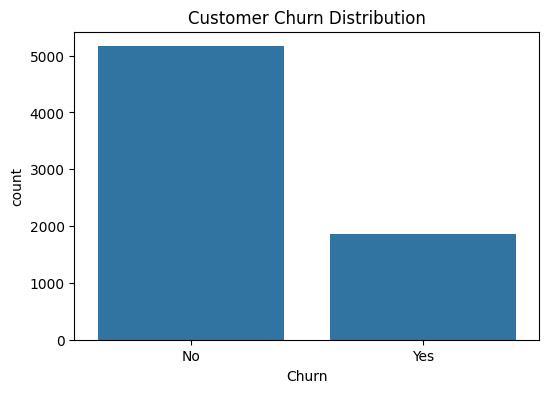

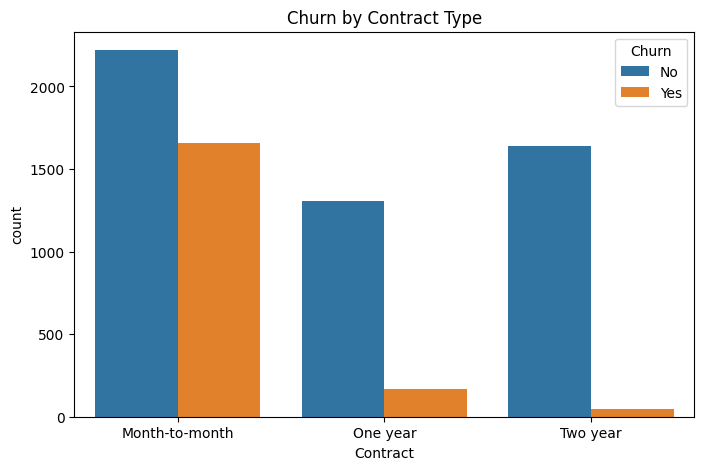

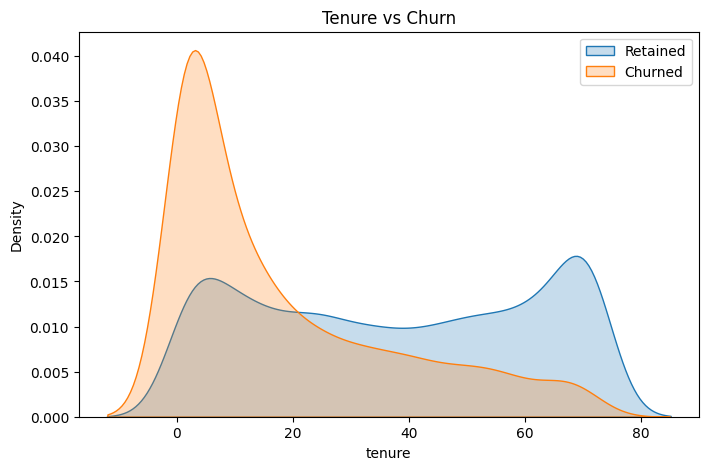

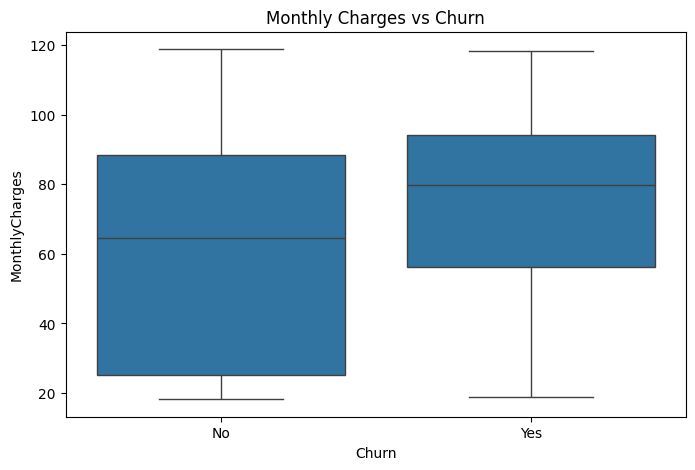

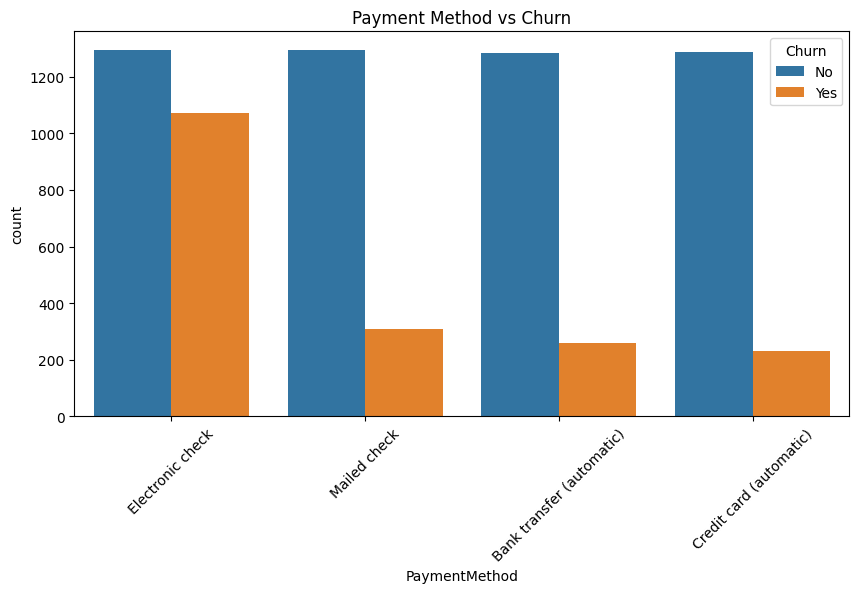


---- Key Insights ----
1. Customers with month-to-month contracts churn more.
2. Customers with shorter tenure are more likely to churn.
3. Higher monthly charges may influence churn behavior.
4. Long-term contracts improve customer retention.


In [7]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  LOAD DATASET
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

#  DISPLAY FIRST 5 ROWS
print("First 5 Rows")
print(df.head())

# DATASET INFO
print("\nDataset Info")
print(df.info())

#  DATA CLEANING
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# CHURN RATE
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print("\nOverall Churn Rate:")
print(churn_counts)

# CHURN DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.show()

# CONTRACT TYPE VS CHURN
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()

#  TENURE VS CHURN
plt.figure(figsize=(8,5))
sns.kdeplot(df[df['Churn']=="No"]['tenure'], label="Retained", fill=True)
sns.kdeplot(df[df['Churn']=="Yes"]['tenure'], label="Churned", fill=True)
plt.title("Tenure vs Churn")
plt.legend()
plt.show()

#  MONTHLY CHARGES VS CHURN
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

#  PAYMENT METHOD VS CHURN
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

# KEY INSIGHTS
print("\n---- Key Insights ----")
print("1. Customers with month-to-month contracts churn more.")
print("2. Customers with shorter tenure are more likely to churn.")
print("3. Higher monthly charges may influence churn behavior.")
print("4. Long-term contracts improve customer retention.")